In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
# Configure plotting style
sns.set(style='whitegrid')
import sys
sys.path.append("../scripts")


In [2]:
from loader import load_data
import pandas as pd


df = load_data("../data/MachineLearningRating_v3.txt")

load_data loaded


/home/sasa/Documents/code/KIAM/week3/notebook/../scripts/loader.py:5: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep='|')


Data discribtion

In [21]:
#Shape, types, nulls, duplicates
from data_preparation import MyEDA

MyEDA.analyze_data(df)

Shape: (999805, 50)
Types:
 UnderwrittenCoverID                  int64
PolicyID                             int64
TransactionMonth            datetime64[ns]
IsVATRegistered                       bool
Citizenship                         object
LegalType                           object
Title                               object
Language                            object
Bank                                object
AccountType                         object
MaritalStatus                       object
Gender                              object
Country                             object
Province                            object
PostalCode                           int64
MainCrestaZone                      object
SubCrestaZone                       object
ItemType                            object
mmcode                             float64
VehicleType                         object
RegistrationYear                     int64
make                                object
Model                     

Column names

In [69]:
#col names
print(MyEDA.list_cols(df))  # List all column names in the DataFrame


Index(['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth',
       'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode',
       'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders',
       'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors',
       'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff',
       'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet',
       'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm',
       'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section',
       'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium',
       'TotalClaims'],
      dtype='object')


Null values

In [5]:
print("Nulls:\n", df.isnull().sum())

Nulls:
 UnderwrittenCoverID              0
PolicyID                         0
TransactionMonth                 0
IsVATRegistered                  0
Citizenship                      0
LegalType                        0
Title                            0
Language                         0
Bank                             0
AccountType                      0
MaritalStatus                    0
Gender                           0
Country                          0
Province                         0
PostalCode                       0
MainCrestaZone                   0
SubCrestaZone                    0
ItemType                         0
mmcode                         552
VehicleType                    552
RegistrationYear                 0
make                           552
Model                          552
Cylinders                      552
cubiccapacity                  552
kilowatts                      552
bodytype                       552
NumberOfDoors                  552
VehicleIntro

In [79]:

MyEDA.num_of_nulls(df,"CustomValueEstimate")

np.float64(0.7795656025709481)

70% of CustomValueEstimate is null there for it is droped

In [80]:
df.drop(columns=['CustomValueEstimate'], inplace=True)


In [4]:
# Drop columns with excessive missing data
columns_to_drop = ['CrossBorder', 'NumberOfVehiclesInFleet']
df.drop(columns=columns_to_drop, inplace=True)
print(f"Dropped columns: {columns_to_drop}")

# Impute missing values
df['Bank'].fillna('Unknown', inplace=True)
df['AccountType'].fillna('Unknown', inplace=True)
df['MaritalStatus'].fillna('Unknown', inplace=True)
df['Gender'].fillna('Unknown', inplace=True)
df['CustomValueEstimate'].fillna(df['CustomValueEstimate'].median(), inplace=True)

# Verify missing values are handled
print("Remaining Missing Values:")
print(df.isnull().sum())


Dropped columns: ['CrossBorder', 'NumberOfVehiclesInFleet']
Remaining Missing Values:


/tmp/ipykernel_7997/2484297751.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Bank'].fillna('Unknown', inplace=True)
/tmp/ipykernel_7997/2484297751.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

UnderwrittenCoverID              0
PolicyID                         0
TransactionMonth                 0
IsVATRegistered                  0
Citizenship                      0
LegalType                        0
Title                            0
Language                         0
Bank                             0
AccountType                      0
MaritalStatus                    0
Gender                           0
Country                          0
Province                         0
PostalCode                       0
MainCrestaZone                   0
SubCrestaZone                    0
ItemType                         0
mmcode                         552
VehicleType                    552
RegistrationYear                 0
make                           552
Model                          552
Cylinders                      552
cubiccapacity                  552
kilowatts                      552
bodytype                       552
NumberOfDoors                  552
VehicleIntroDate    

In [20]:
#data converstion 
#data converstion 

from data_preparation import MyEDA

df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'])
print("TransactionMonth converted to datetime format!")



TransactionMonth converted to datetime format!


In [12]:
print(df["Bank"].count()) 
print(df["Bank"].unique()) # Unique banks in the dataset
print(df["Bank"].value_counts())  # Count of ratings per bank
print(df["Bank"].nunique())  # Number of unique banks

854137
['First National Bank' 'Standard Bank' nan 'ABSA Bank' 'Capitec Bank'
 'Nedbank' 'FirstRand Bank' 'Investec Bank' 'Ithala Bank' 'Old Mutual'
 'Mercantile Lisbon Bank' 'RMB Private Bank']
Bank
First National Bank       260811
ABSA Bank                 204954
Standard Bank             181715
Nedbank                   132003
Capitec Bank               58155
RMB Private Bank           12576
Ithala Bank                 1730
Investec Bank                732
Old Mutual                   688
FirstRand Bank               638
Mercantile Lisbon Bank       135
Name: count, dtype: int64
11


In [7]:
# handle outliers
df = df[(df['TotalPremium'] >= 0) & (df['TotalClaims'] >= 0)]
print("Filtered rows with negative TotalPremium and TotalClaims.")



Filtered rows with negative TotalPremium and TotalClaims.


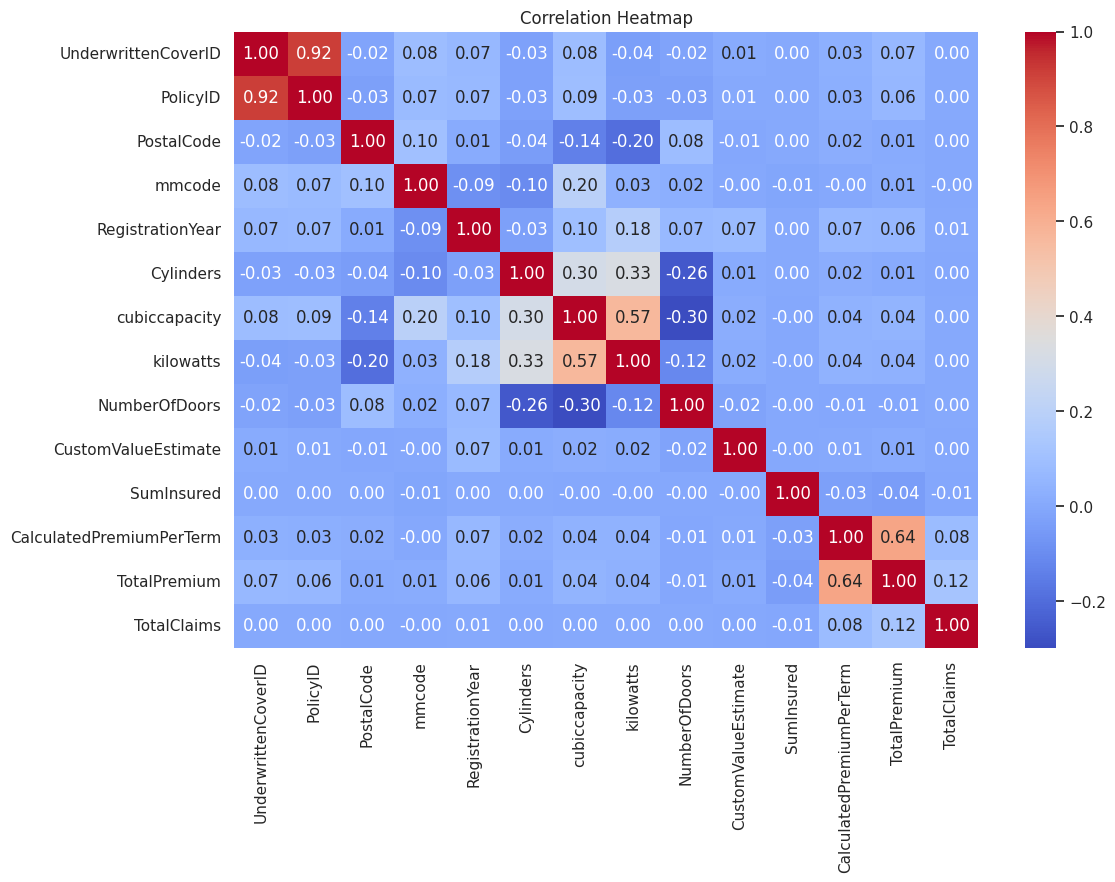

In [8]:
# Filter only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Generate correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [9]:
# Identify columns with non-numeric values
for col in numeric_df.columns:
    try:
        pd.to_numeric(df[col])
    except ValueError:
        print(f"Non-numeric values found in column: {col}")


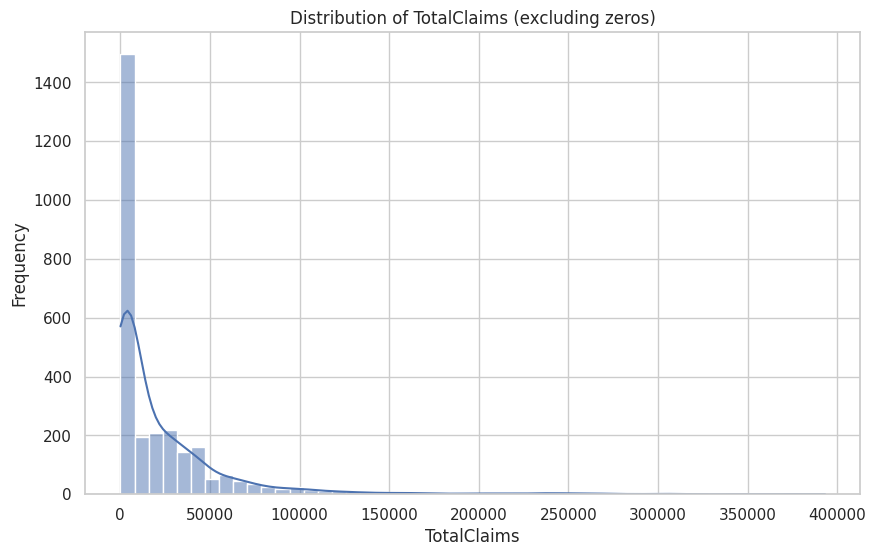

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['TotalClaims'] > 0]['TotalClaims'], bins=50, kde=True)
plt.title('Distribution of TotalClaims (excluding zeros)')
plt.xlabel('TotalClaims')
plt.ylabel('Frequency')
plt.show()


/home/sasa/Documents/code/KIAM/week3/notebook/../scripts/Visuals.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=series.values, y=series.index, palette='viridis')


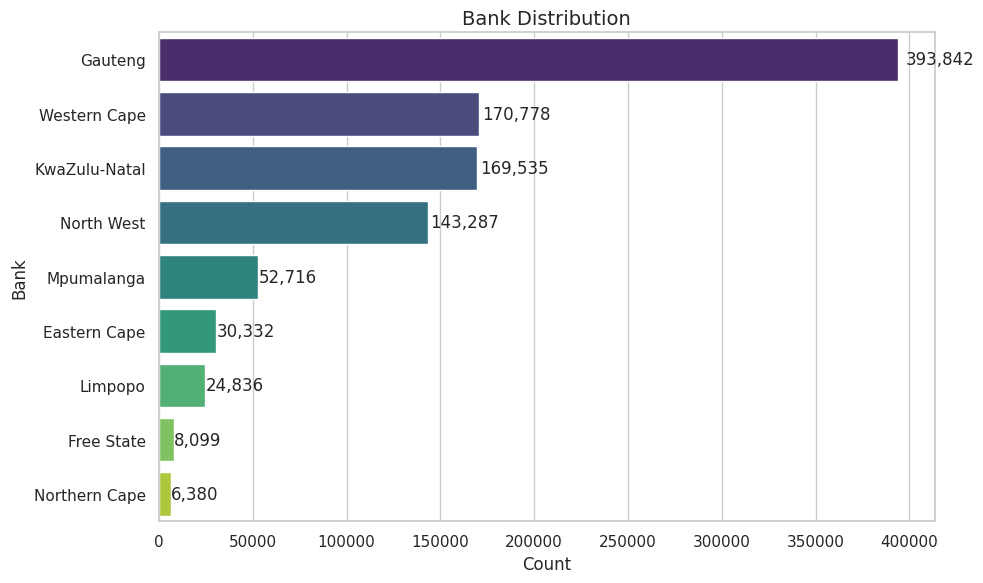

In [19]:
# Distribution counts for Province, Gender, VehicleType
from Visuals import bars

province =df['Province'].value_counts()
title = "Province Distribution"
bars(province)


<string>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



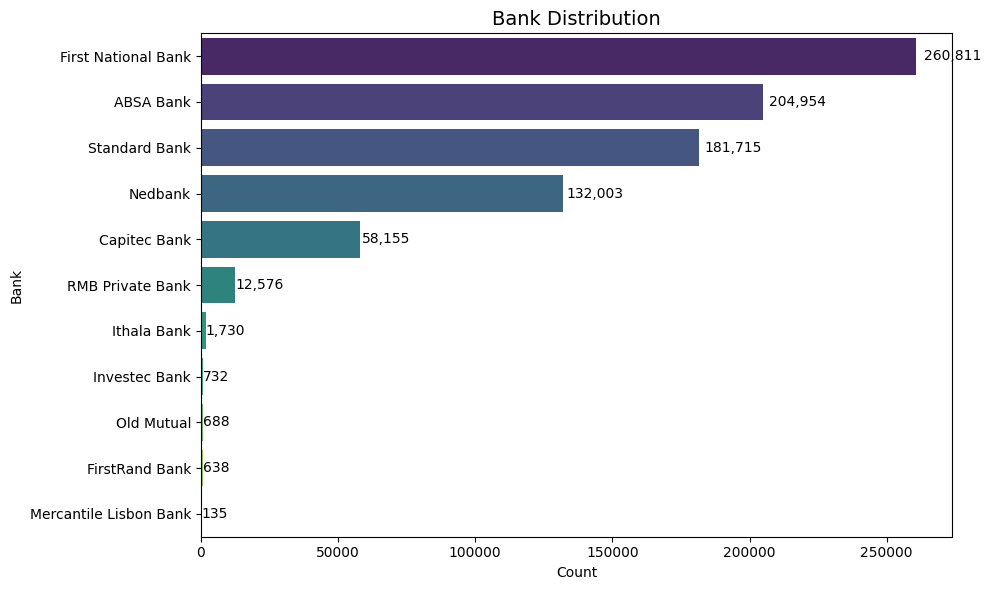

In [75]:
from Visuals import bars

# data
bank_counts = df["Bank"].value_counts()

# plot
bars(bank_counts)
